In [27]:
import warnings
import itertools
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
from pathlib import Path

In [28]:
for p in Path().iterdir():
    print(p)

retail_clean.csv
.DS_Store
supply.ipynb
timeseries_rev.csv
modeling.ipynb
README.md
section+11.py
Section_10_revised_2.py
.git
error.ipynb


In [29]:
newData = Path("timeseries_rev.csv")

In [5]:
print(newData.absolute())

/Users/williethomas/Desktop/forcasting_supply_cain/supplychain/timeseries_rev.csv


In [30]:
time_series = pd.read_csv(newData.absolute(),parse_dates=True)

In [31]:
# set the date as index
time_series.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     104 non-null    int64  
 1   week           104 non-null    int64  
 2   year           104 non-null    int64  
 3   date           104 non-null    object 
 4   total_revenue  104 non-null    float64
dtypes: float64(1), int64(3), object(1)
memory usage: 4.2+ KB


In [32]:
time_series['date'] = pd.to_datetime(time_series['date']) 



In [33]:
time_series = time_series.set_index('date') 

In [35]:
monthly_series = time_series.total_revenue.resample('M').sum()

<AxesSubplot:xlabel='date'>

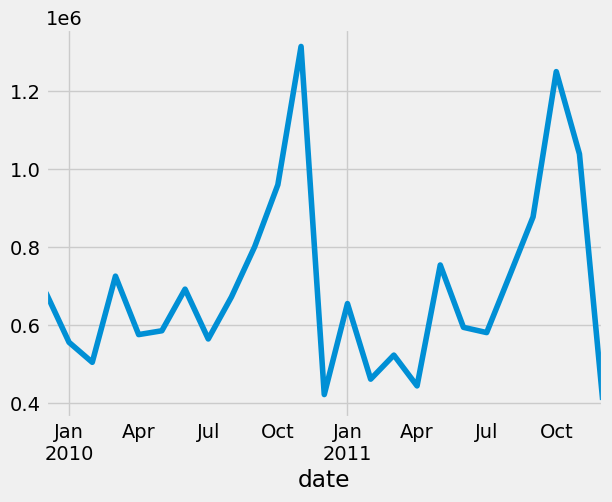

In [36]:
monthly_series.plot()

In [39]:
components = sm.tsa.seasonal_decompose(monthly_series)

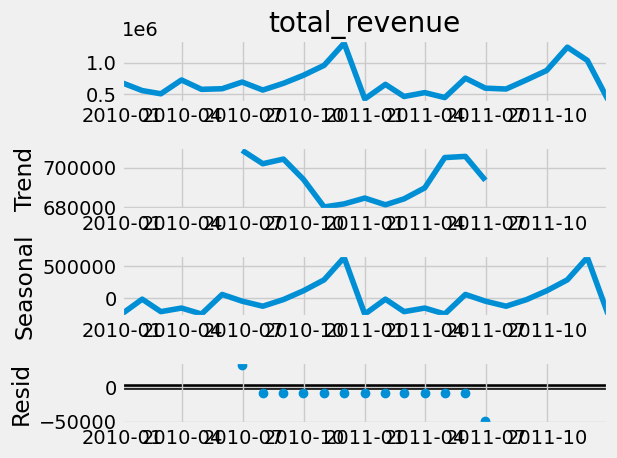

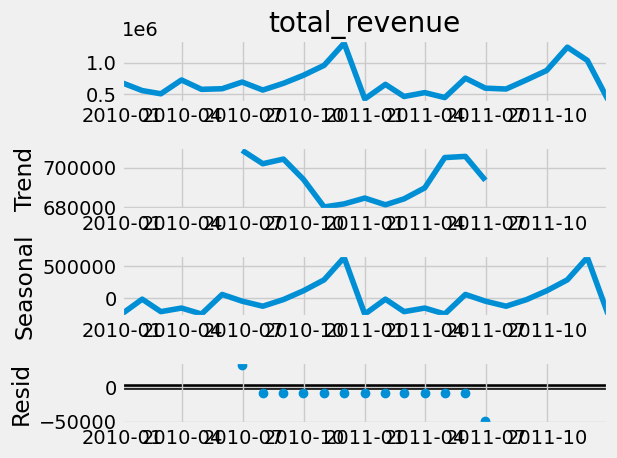

In [40]:
components.plot()

In [41]:
trend = components.trend

In [42]:
seasonality= components.seasonal

In [45]:
remainder = components.resid

<AxesSubplot:xlabel='date'>

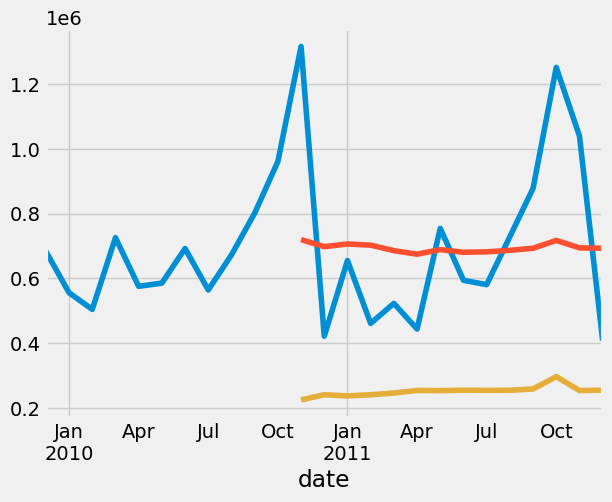

In [46]:
#checking for stationarity 

monthly_series.plot()
monthly_series.rolling(window=12).mean().plot()
monthly_series.rolling(window=12).std().plot()





In [47]:
ad_fuller_test = sm.tsa.stattools.adfuller(monthly_series, autolag='AIC' )
ad_fuller_test

(-3.65387092800058,
 0.00481082553082401,
 9,
 15,
 {'1%': -3.9644434814814815,
  '5%': -3.0849081481481484,
  '10%': -2.6818144444444445},
 418.7649518406608)

In [48]:
from statsmodels.graphics.tsaplots import plot_acf , plot_pacf

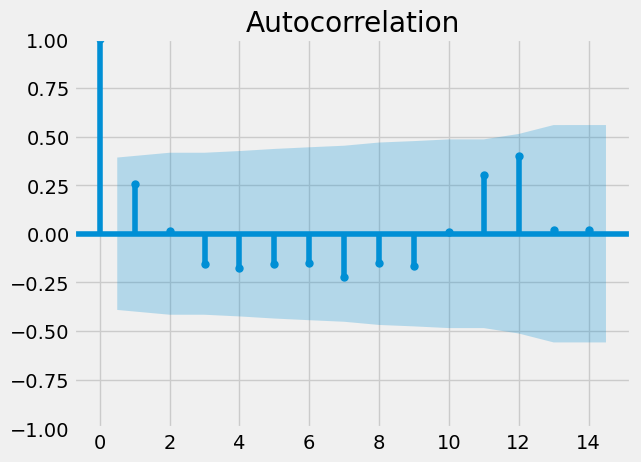

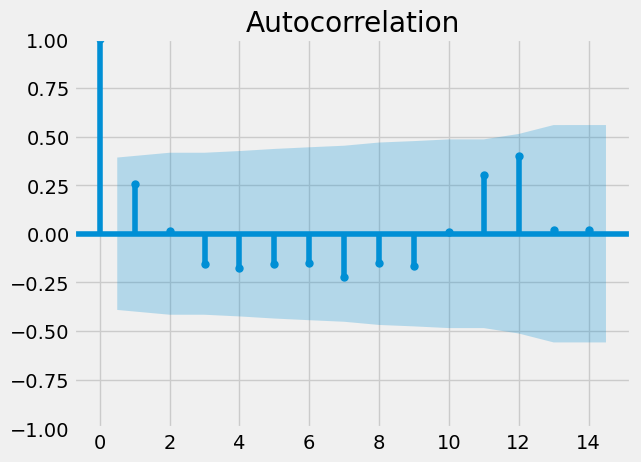

In [49]:
plot_acf(monthly_series)